***Sound Event Detection***  
This notebook uses the panns_inference and webrtcvad libraries to explore the various sonic elements of a peice of audio. It particularly focuses on the detection and location of human speech within audio. This notebook was designed to assist exploration of audio recordings from the PARADISEC collection.

This code loads in the .wav file which is to be analyzed, then does the majority of the data processing. It ultimately creates the audio_tags and speech_tags lists, which contain audio labels for each second of the audio.

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

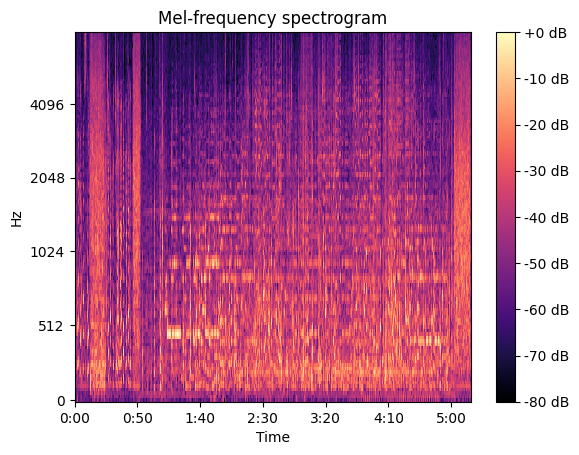

In [ ]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
from panns_inference import AudioTagging, SoundEventDetection, labels
audio_file_path="/content/William_Shatner_Sings_Rocket_Man_1978_-_BEST_QUALITY-lul-Y8vSr0I.mp3"
(audio,sr)=librosa.core.load(audio_file_path,sr=48000,mono=True)
S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128,fmax=8000)
fig, ax = plt.subplots()
S_dB = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_dB, x_axis='time',y_axis='mel', sr=sr,fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')

In [ ]:
import librosa
import panns_inference
import numpy as np
import webrtcvad
from pydub import AudioSegment
chunk_duration=1
chunk_samples=int(sr*chunk_duration)
chunks = [audio[i:i + chunk_samples] for i in range(0, len(audio)-len(audio)%chunk_samples, chunk_samples)]
audio_tags=[]
speech_tags=[]
at=AudioTagging(checkpoint_path=None, device='cuda')
vad=webrtcvad.Vad()
for i in chunks:
  inp16 = (i * 32767).astype(np.int16)
  inp = i[None, :]
  num_splits=100
  rt=0
  for j in range(num_splits):
    temp=inp16[j*sr*chunk_duration//num_splits:(j+1)*sr*chunk_duration//num_splits]
    if vad.is_speech(temp.tobytes(),sr):
      rt+=1
  if rt>=50:
    speech_tags.append(True)
  else:
    speech_tags.append(False)
  chunkwise_output,embedding=at.inference(inp)
  scores = chunkwise_output[0]
  top_indices = np.argsort(scores)[::-1][:6]
  audio_tags.append([])
  for j in top_indices:
    audio_tags[-1].append((labels[j],scores[j]))

Checkpoint path: /root/panns_data/Cnn14_mAP=0.431.pth
Using CPU.


This code returns the audio labels and speech detection for each requested second of the audio. Enter a range of seconds (ie. 0-5, 52-60) to see the information for each.

In [ ]:
high=0
low=0
while not (low<high):
  indices=input("Which range of seconds would you like information for? (ie. 0-10, 20-22): ")
  low,high=indices.split("-")
  low=int(low)
  high=int(high)
  if not (low<high):
    print("Not a valid range")
for i in range(low,high+1):
  print("Second "+str(i)+": ")
  for j in audio_tags[i]:
    print(j[0]+": "+str(j[1]))
  print("VAD speech detected: "+str(speech_tags[i]))
  print()


Which range of seconds would you like information for? (ie. 0-10, 20-22): 22-24
Second 22: 
Speech: 0.50120133
Music: 0.08430851
Narration, monologue: 0.051810738
Male speech, man speaking: 0.05133242
Inside, small room: 0.043366726
Speech synthesizer: 0.040074296
VAD speech detected: True

Second 23: 
Music: 0.1291049
Speech: 0.123455405
Musical instrument: 0.04990427
Inside, small room: 0.038945165
Silence: 0.028819624
Narration, monologue: 0.017083677
VAD speech detected: False

Second 24: 
Music: 0.1722158
Speech: 0.08944876
Musical instrument: 0.035799157
Inside, small room: 0.024259409
Animal: 0.017381413
Vehicle: 0.012153643
VAD speech detected: True



This code uses the previously created tags to create a "smart detection" of speech in the audio file. By combining the speech data recieved from the VAD and SED, it predicts whether each second of audio contains speech. By combining the data from two sources, this method provides a more accurate prediction then either source individually.

In [ ]:
speech=[]
for i in range(len(audio_tags)):
  speech.append(0)
  rs=0
  for j in range(len(audio_tags[i])):
    if audio_tags[i][j][0] in ["Speech","Narration, monologue","Male speech, man speaking","Female speech, woman speaking","Mantra"]:
      if audio_tags[i][j][1]>0.6 or j==0:
        speech[-1]=2
        break
      if j==1 and audio_tags[i][0][1]<0.4 and audio_tags[i][j][1]>.1:
        speech[-1]=1
      rs+=audio_tags[i][j][1]
  if rs>=1.2:
    speech[-1]=2
  elif speech_tags[i]:
    speech[-1]=2
  elif rs>=.8 and speech[-1]==0:
    speech[-1]=1
final=[]
if (speech[0]==1 and speech[1]==2) or speech[0]==2:
  final.append(True)
else:
  final.append(False)
for i in range(1,len(speech)-1):
  if speech[i]==2:
    final.append(True)
  elif speech[i]==1 and (speech[i-1]+speech[i+1]>=3):
    final.append(True)
  else:
    final.append(False)
if speech[-1]==2 or (speech[-1]==1 and speech[-2]==2):
  final.append(True)
else:
  final.append(False)
for i in range(len(final)):
  print(str(i)+" "+str(final[i]))




0 False
1 False
2 False
3 False
4 False
5 False
6 False
7 False
8 True
9 True
10 True
11 False
12 True
13 True
14 False
15 True
16 True
17 True
18 False
19 True
20 True
21 True
22 True
23 True
24 True
25 True
26 True
27 False
28 True
29 True
30 True
31 True
32 True
33 True
34 True
35 True
36 True
37 True
38 True
39 False
40 True
41 True
42 False
43 False
44 True
45 True
46 True
47 False
48 True
49 True
50 True
51 False
52 True
53 True
54 True
55 False
56 True
57 True
58 True
59 True
60 False
61 False
62 True
63 True
64 True
65 False
66 True
67 True
68 False
69 False
70 True
71 True
72 False
73 True
74 True
75 True
76 True
77 False
78 False
79 False
80 False
81 False
82 False
83 False
84 False
85 False
86 False
87 False
88 False
89 False
90 False
91 False
92 False
93 False
94 False
95 False
96 True
97 True
98 True
99 True
100 True
101 True
102 True
103 True
104 True
105 True
106 True
107 True
108 True
109 True
110 True
111 True
112 True
113 True
114 True
115 True
116 True
117 True
118 T

This code does further label prediction on the audio, structuring the resulting tags in a way that allows the tags to be graphed over time.

In [ ]:
import matplotlib.pyplot as plt
sed = SoundEventDetection(checkpoint_path=None, device='cuda')
audioin=audio[None, :]
framewise_output = sed.inference(audioin)

Checkpoint path: /root/panns_data/Cnn14_DecisionLevelMax.pth
Using CPU.


Graphs the confidence of the five most prevalent audio tags over the course of the audio. Saves the graph as "output_graph.png"

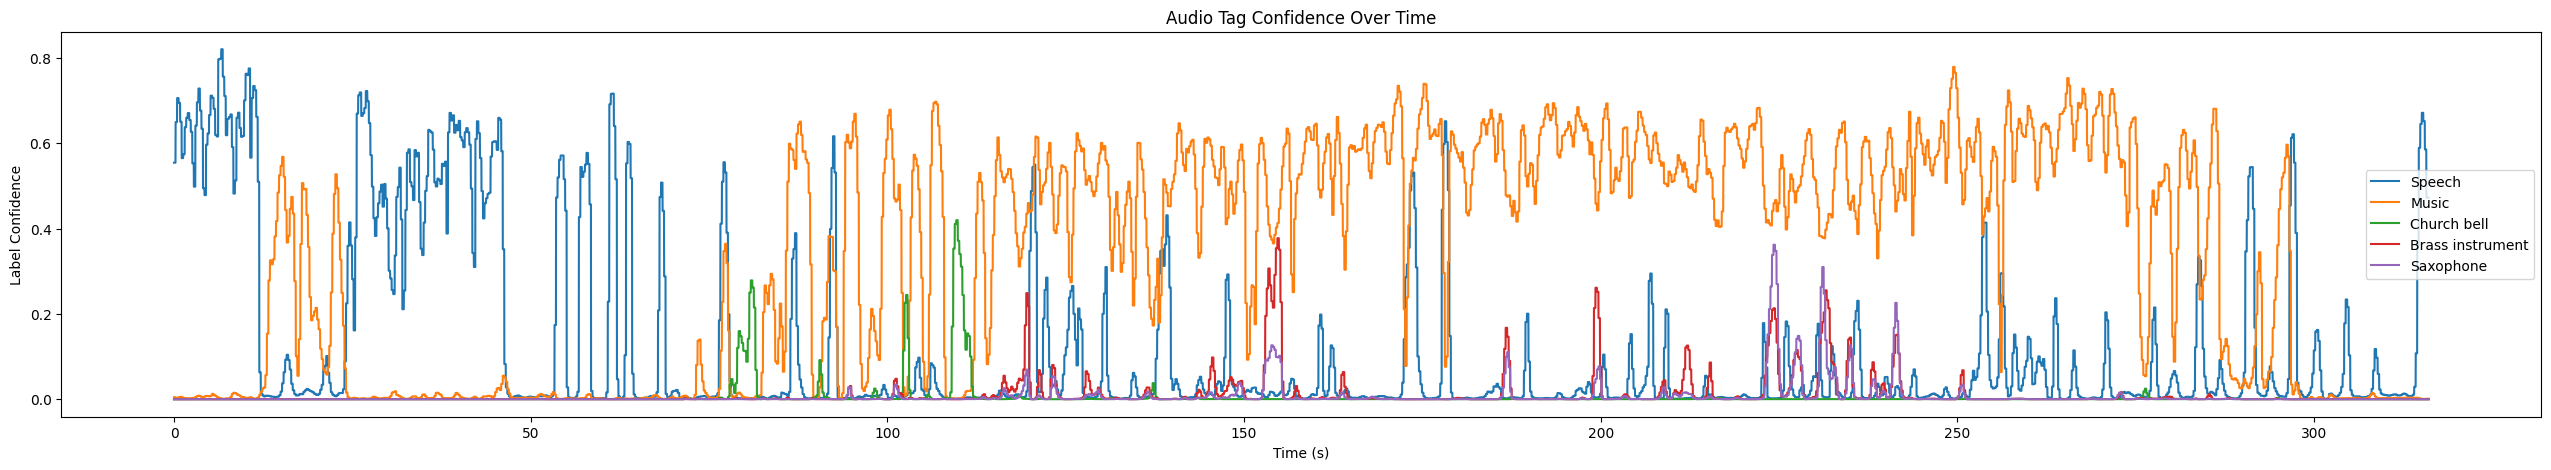

In [ ]:
output = framewise_output[0]
top_n = 5
time = np.arange(output.shape[0])/48000*320
plt.figure(figsize=(max(round(max(time)/10),7), 5))
top_classes = np.argsort(output.max(axis=0))[::-1][:top_n]
for i in top_classes:
    label = sed.labels[i]
    plt.plot(time, output[:, i], label=label)
plt.legend()
plt.title("Audio Tag Confidence Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Label Confidence")
plt.savefig("output_graph.png")